# Distribution Diagnostics with `tools21cm`

The `PosteriorDiagnostic` family of classes lets you **compare and diagnose probability distributions** — whether they come from scientific inference, simulations, machine learning, or any other source.

You can answer questions like:
- Does my model recover the true parameter?
- Which of two methods gives tighter or more accurate estimates?
- Is my distribution biased or overconfident?

## Two input flavours

| Class | Input | Typical use |
|---|---|---|
| `SampledDistribution` | Array of samples (+ optional weights) | MCMC chains, Monte Carlo draws, bootstrap replicates |
| `GriddedProbabilities` | N-D array of probability values on a grid | Analytic densities, histograms, likelihood grids |

Both share the same plotting and metric interface.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tools21cm.plotting import SampledDistribution, GriddedProbabilities

rng = np.random.default_rng(42)

---
## 1. Basic usage — single distribution

Pass any 2-D array of shape `(n_samples, n_params)`.  
Provide `true_values` to unlock diagnostic metrics.

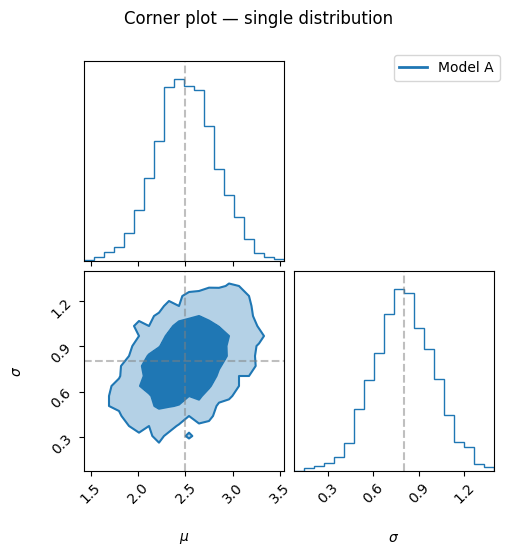

In [2]:
# 2-parameter distribution — e.g. mean and std of some process
true_vals = [2.5, 0.8]

samples = rng.multivariate_normal(
    mean=true_vals,
    cov=[[0.10, 0.03], [0.03, 0.04]],
    size=3000
)

diag = SampledDistribution(
    true_values=true_vals,
    param_labels=[r'\mu', r'\sigma']
)
diag.add_distribution(samples, label='Model A')

fig = diag.plot_corner()
plt.suptitle('Corner plot — single distribution', y=1.02)
plt.show()

---
## 2. Comparing multiple distributions

Call `add_distribution` multiple times.  
Useful for comparing methods, priors, or approximations against each other.

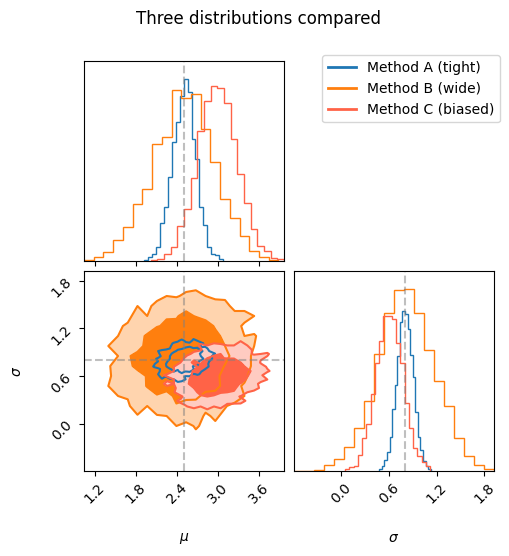

In [3]:
tight  = rng.multivariate_normal(true_vals, [[0.03, 0.005],[0.005, 0.01]], 3000)
wide   = rng.multivariate_normal(true_vals, [[0.20, 0.01 ],[0.01,  0.12]], 3000)
biased = rng.multivariate_normal([3.0, 0.6], [[0.08, 0.01],[0.01, 0.03]], 3000)

multi = SampledDistribution(
    true_values=true_vals,
    param_labels=[r'\mu', r'\sigma']
)
multi.add_distribution(tight,  label='Method A (tight)')
multi.add_distribution(wide,   label='Method B (wide)')
multi.add_distribution(biased, label='Method C (biased)', color='tomato')

fig = multi.plot_corner()
plt.suptitle('Three distributions compared', y=1.02)
plt.show()

---
## 3. Forest plot — credible intervals at a glance

`plot_forest()` shows **68% and 95% credible intervals** for every distribution side by side.  
The dashed line marks the true value. Great for quick multi-model comparisons.

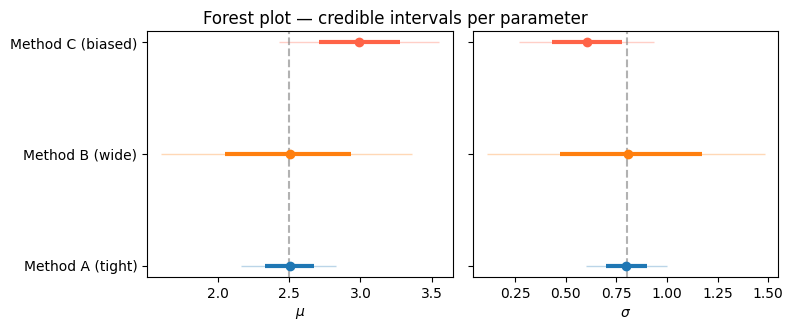

In [4]:
fig = multi.plot_forest()
plt.suptitle('Forest plot — credible intervals per parameter', y=1.02)
plt.show()

---
## 4. Diagnostic metrics

When `true_values` is provided, the class computes several calibration diagnostics automatically.

| Metric | What it measures | Ideal value |
|--------|-----------------|-------------|
| **Z-score** | Distance from truth in units of std dev | 0 |
| **PIT** | CDF evaluated at truth (should be ~0.5 for unbiased) | 0.5 |
| **Bias** | Mean estimate minus truth | 0 |
| **RMSE** | Root mean square error across parameters | 0 |
| **Mahalanobis** | Multivariate distance accounting for correlations | 1 |
| **Coverage** | Whether truth falls inside 68% / 95% interval | True |

In [5]:
param_names = ['μ', 'σ']

for name, dist in multi.distributions.items():
    s = dist['stats']
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    for p, lbl in enumerate(param_names):
        ci = s['cis'][p]
        print(f"  {lbl}: median={ci['median']:.3f}  "
              f"68% CI=[{ci['lo1']:.3f}, {ci['hi1']:.3f}]")
    if 'z_scores' in s:
        print(f"  Z-scores   : {np.round(s['z_scores'], 2)}  (ideal: 0)")
        print(f"  PIT        : {np.round(s['pit'], 2)}  (ideal: 0.5)")
        print(f"  RMSE       : {s['rmse']:.4f}  (ideal: 0)")
        print(f"  Mahalanobis: {s['mahalanobis']:.3f}  (ideal: 1)")
        print(f"  Cover 68%  : {s['cover_68']}")
        print(f"  Cover 95%  : {s['cover_95']}")


  Method A (tight)
  μ: median=2.508  68% CI=[2.332, 2.675]
  σ: median=0.799  68% CI=[0.699, 0.902]
  Z-scores   : [0.02 0.  ]  (ideal: 0)
  PIT        : [0.48 0.5 ]  (ideal: 0.5)
  RMSE       : 0.0025  (ideal: 0)
  Mahalanobis: 0.022  (ideal: 1)
  Cover 68%  : [ True  True]
  Cover 95%  : [ True  True]

  Method B (wide)
  μ: median=2.509  68% CI=[2.052, 2.934]
  σ: median=0.808  68% CI=[0.470, 1.171]
  Z-scores   : [0.01 0.03]  (ideal: 0)
  PIT        : [0.49 0.49]  (ideal: 0.5)
  RMSE       : 0.0083  (ideal: 0)
  Mahalanobis: 0.033  (ideal: 1)
  Cover 68%  : [ True  True]
  Cover 95%  : [ True  True]

  Method C (biased)
  μ: median=2.987  68% CI=[2.710, 3.275]
  σ: median=0.604  68% CI=[0.434, 0.776]
  Z-scores   : [1.72 1.15]  (ideal: 0)
  PIT        : [0.04 0.88]  (ideal: 0.5)
  RMSE       : 0.3730  (ideal: 0)
  Mahalanobis: 2.310  (ideal: 1)
  Cover 68%  : [False False]
  Cover 95%  : [ True  True]


---
## 5. Weighted samples

Pass a `weights` array to represent non-uniform importance (e.g. importance sampling, nested sampling dead points).  
Weights need not be normalised.

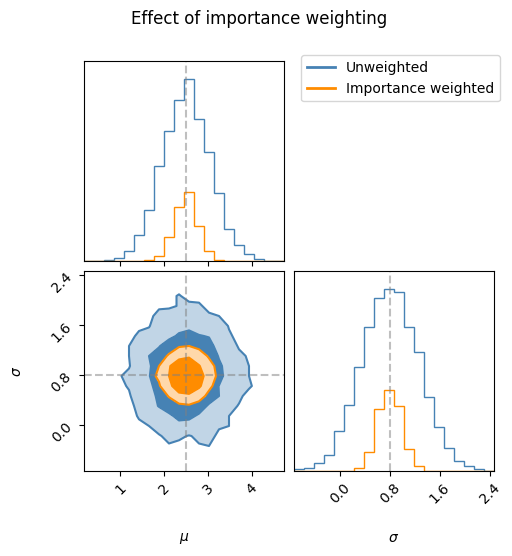

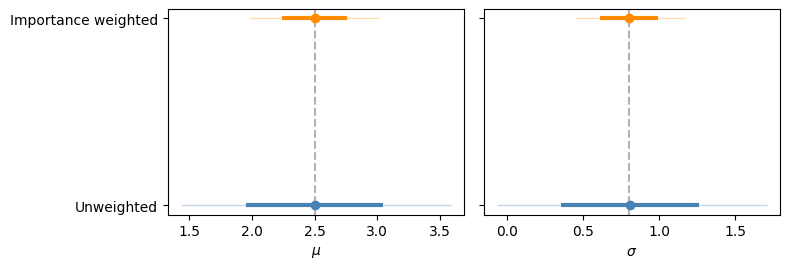

In [6]:
raw_samples = rng.multivariate_normal([2.5, 0.8], [[0.3,0],[0,0.2]], size=5000)

# Importance weights: upweight samples near the true value
log_w = -0.5 * np.sum(((raw_samples - true_vals) / [0.3, 0.2])**2, axis=1)
importance_weights = np.exp(log_w - log_w.max())

diag_w = SampledDistribution(
    true_values=true_vals,
    param_labels=[r'\mu', r'\sigma']
)
diag_w.add_distribution(raw_samples, label='Unweighted', color='steelblue')
diag_w.add_distribution(raw_samples, weights=importance_weights, label='Importance weighted', color='darkorange')

fig = diag_w.plot_corner()
plt.suptitle('Effect of importance weighting', y=1.02)
plt.show()

fig = diag_w.plot_forest()
plt.show()

---
## 6. `GriddedProbabilities` — grid-based distributions

If your distribution is defined on a grid (e.g. a 2-D likelihood surface, a histogram), use `GriddedProbabilities` instead.  
The grid values are treated as (unnormalised) probability weights.

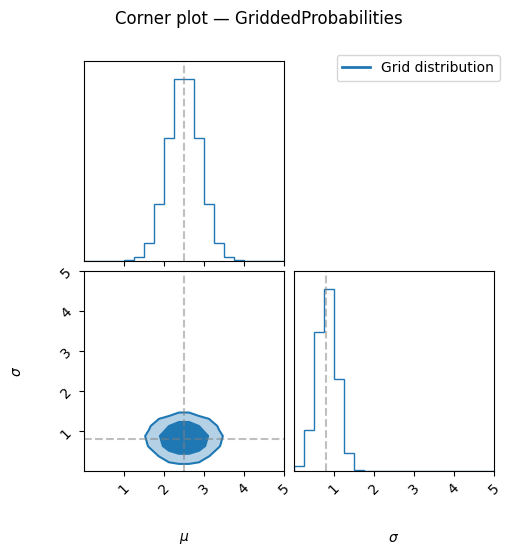

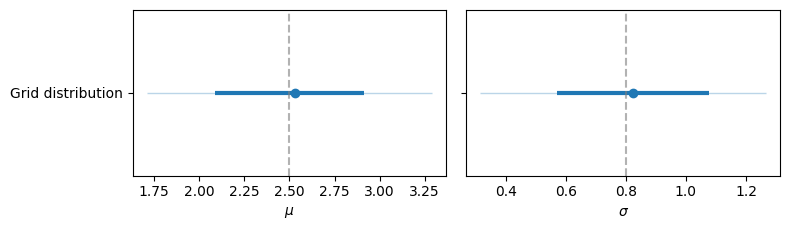

In [7]:
# Build a 2-D Gaussian probability grid
coords = np.linspace(0, 5, 80)
x, y = np.meshgrid(coords, coords, indexing='ij')
grid = np.exp(-0.5 * (((x - 2.5)/0.4)**2 + ((y - 0.8)/0.25)**2))

gdiag = GriddedProbabilities(
    coords_1d=coords,
    true_values=true_vals,
    param_labels=[r'\mu', r'\sigma']
)
gdiag.add_distribution(grid, label='Grid distribution')

fig = gdiag.plot_corner()
plt.suptitle('Corner plot — GriddedProbabilities', y=1.02)
plt.show()

fig = gdiag.plot_forest()
plt.show()

---
## 7. Mixing models with different numbers of parameters

`DistributionDiagnostic` handles distributions over different parameter spaces on the same plot.  
Here a 4-parameter model and a 2-parameter model (a restricted version) are compared — the corner plot shows only the shared axes for the smaller model.

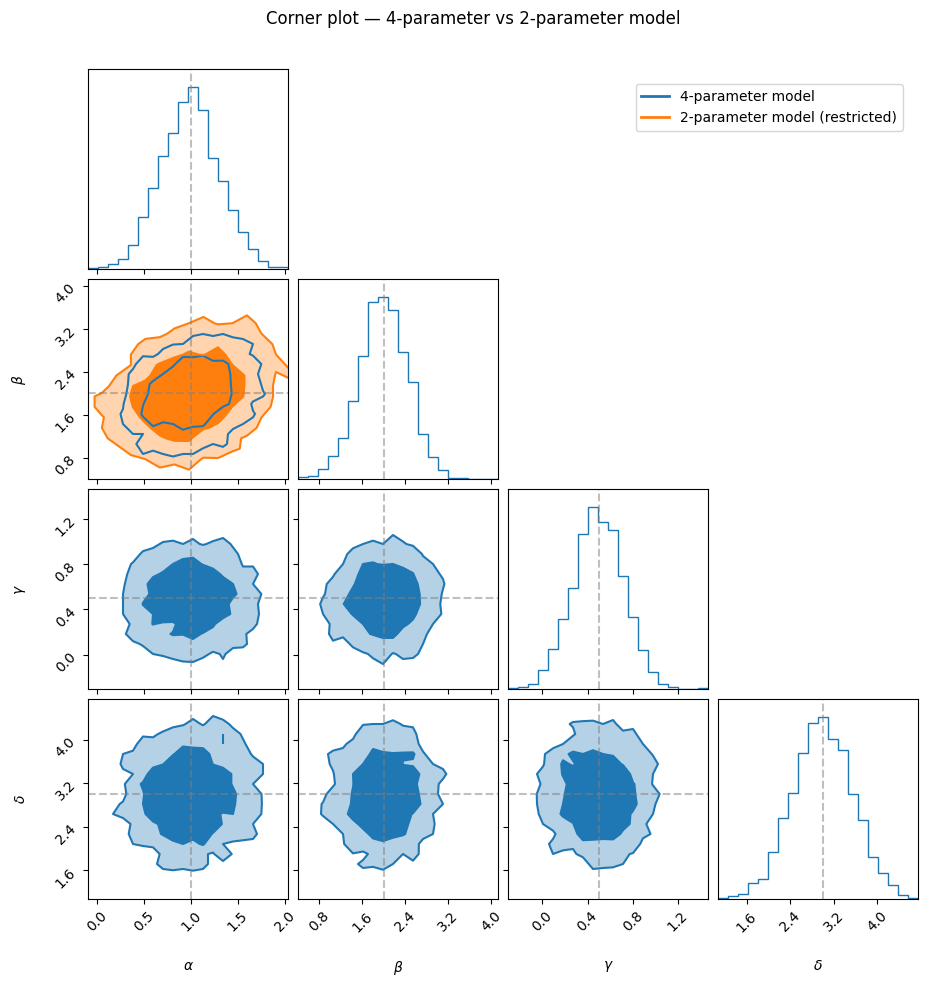

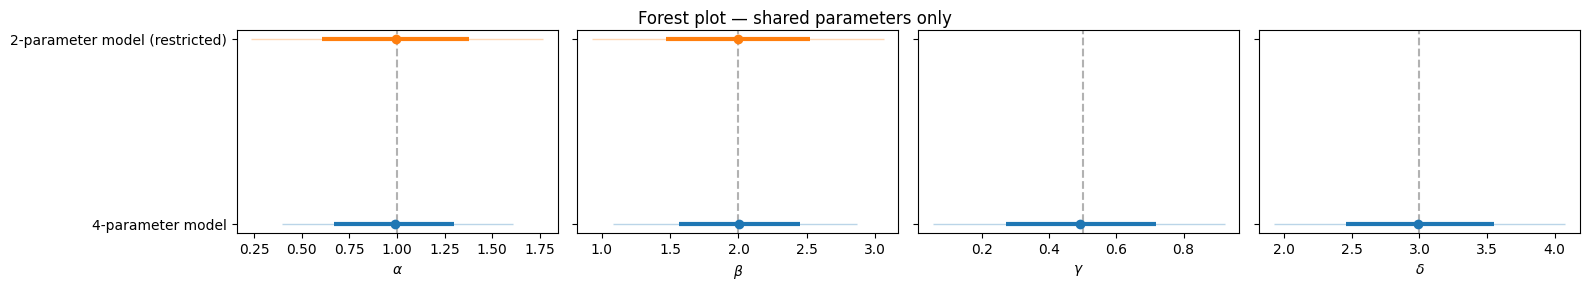

In [8]:
true_4d = [1.0, 2.0, 0.5, 3.0]
cov_4d  = np.diag([0.1, 0.2, 0.05, 0.3])
cov_4d[0, 1] = cov_4d[1, 0] = 0.04  # mild correlation between param 1 and 2

# 4-parameter model
s_4d = rng.multivariate_normal(true_4d, cov_4d, 4000)

# 2-parameter restricted model (only first two parameters)
cov_2d = cov_4d[:2, :2] * 1.5   # wider — restricted model is less constrained
s_2d = rng.multivariate_normal(true_4d[:2], cov_2d, 4000)

diag_mixed = SampledDistribution(
    backend='corner',
    true_values=true_4d,
    param_labels=[r'\alpha', r'\beta', r'\gamma', r'\delta']
)
diag_mixed.add_distribution(s_4d, label='4-parameter model')
diag_mixed.add_distribution(s_2d, label='2-parameter model (restricted)')

fig = diag_mixed.plot_corner()
plt.suptitle('Corner plot — 4-parameter vs 2-parameter model', y=1.02)
plt.show()

fig = diag_mixed.plot_forest()
plt.suptitle('Forest plot — shared parameters only', y=1.02)
plt.show()

---
## 8. `getdist` backend (optional)

Switch the corner-plot renderer by passing `backend='getdist'` at construction.  
Requires `pip install getdist`.

Removed no burn in
Removed no burn in


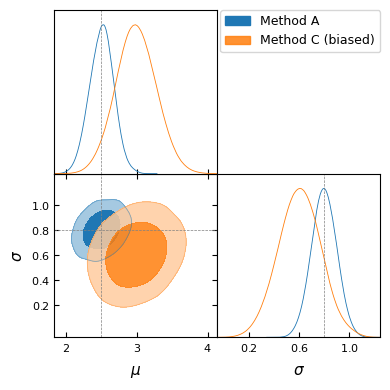

In [9]:
try:
    diag_gd = SampledDistribution(
        backend='getdist',
        true_values=true_vals,
        param_labels=[r'\mu', r'\sigma']
    )
    diag_gd.add_distribution(tight,  label='Method A', color='C0')
    diag_gd.add_distribution(biased, label='Method C (biased)', color='C1')
    g = diag_gd.plot_corner()
    plt.show()
except ImportError:
    print("getdist not installed — skip. Install with: pip install getdist")